🚀 Προετοιμασία δεδομένων...
⚙️  [1/2] Επίλυση Σεναρίου ΧΩΡΙΣ CO2 Cap...
⚙️  [2/2] Επίλυση Σεναρίου ΜΕ CO2 Cap (40,000 Tons)...

🔍 DEBUG: Storage Charge/Discharge Totals (Σενάριο CO2 Cap)
  PumpedHydro: total charge=3,546.2 MWh, total discharge=2,659.7 MWh
  BESS_4h: total charge=45,560.7 MWh, total discharge=40,093.4 MWh

📊 ΣΕΝΑΡΙΟ 1: ΧΩΡΙΣ CO2 CAP
Solver Status:            ok
Συνολικό Κόστος:          €19,400,060.16
Συνολικές Εκπομπές CO2:  31,507.86 Tons
Μέση Οριακή Τιμή (LMP):  €24.38 / MWh
------------------------------------------------------------
🏗️  ΕΠΕΝΔΥΣΕΙΣ ΣΕ ΜΟΝΑΔΕΣ ΠΑΡΑΓΩΓΗΣ (GENERATION):
  • WindNew   : 48 μονάδες (4,800 MW)
  • CCNew     : 0 μονάδες (0 MW)
  • CTNew     : 0 μονάδες (0 MW)
------------------------------------------------------------
🔋 ΕΠΕΝΔΥΣΕΙΣ ΣΕ ΑΠΟΘΗΚΕΥΣΗ (STORAGE):
  • BESS_4h   : 1,943.7 MW / 7,775.0 MWh (4.0h duration)
------------------------------------------------------------
☀️  ΣΥΝΟΛΙΚΟ CURTAILMENT (ΑΝΕΚΜΕΤΑΛΛΕΥΤΟ VRE):
  • Sol1      : 0.00 M

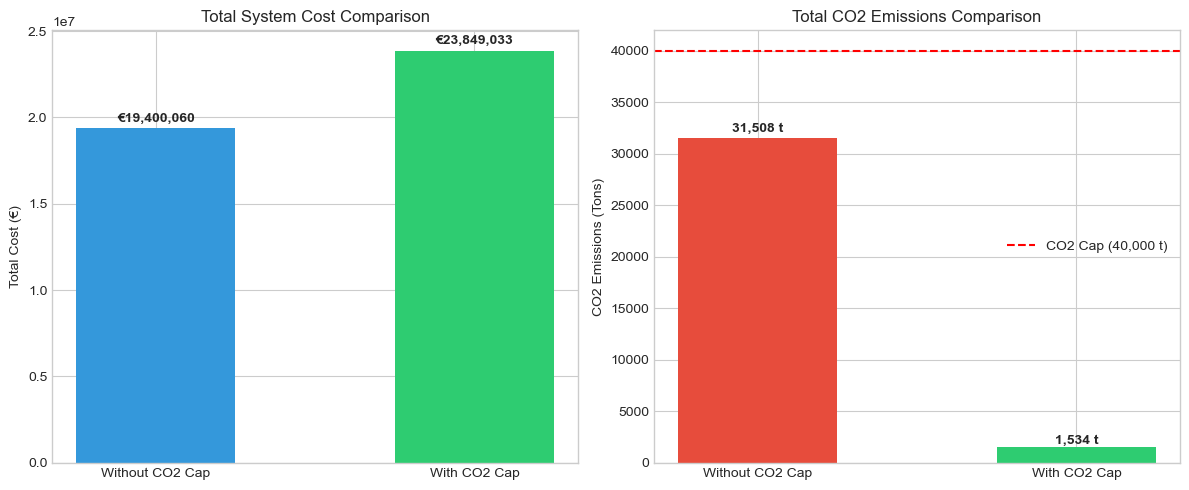

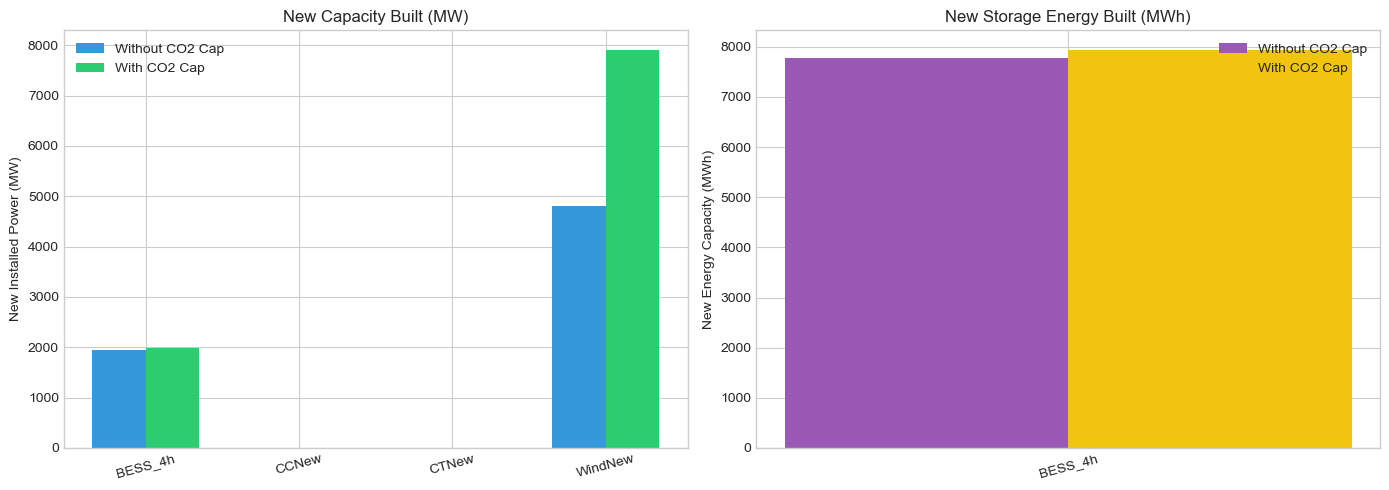

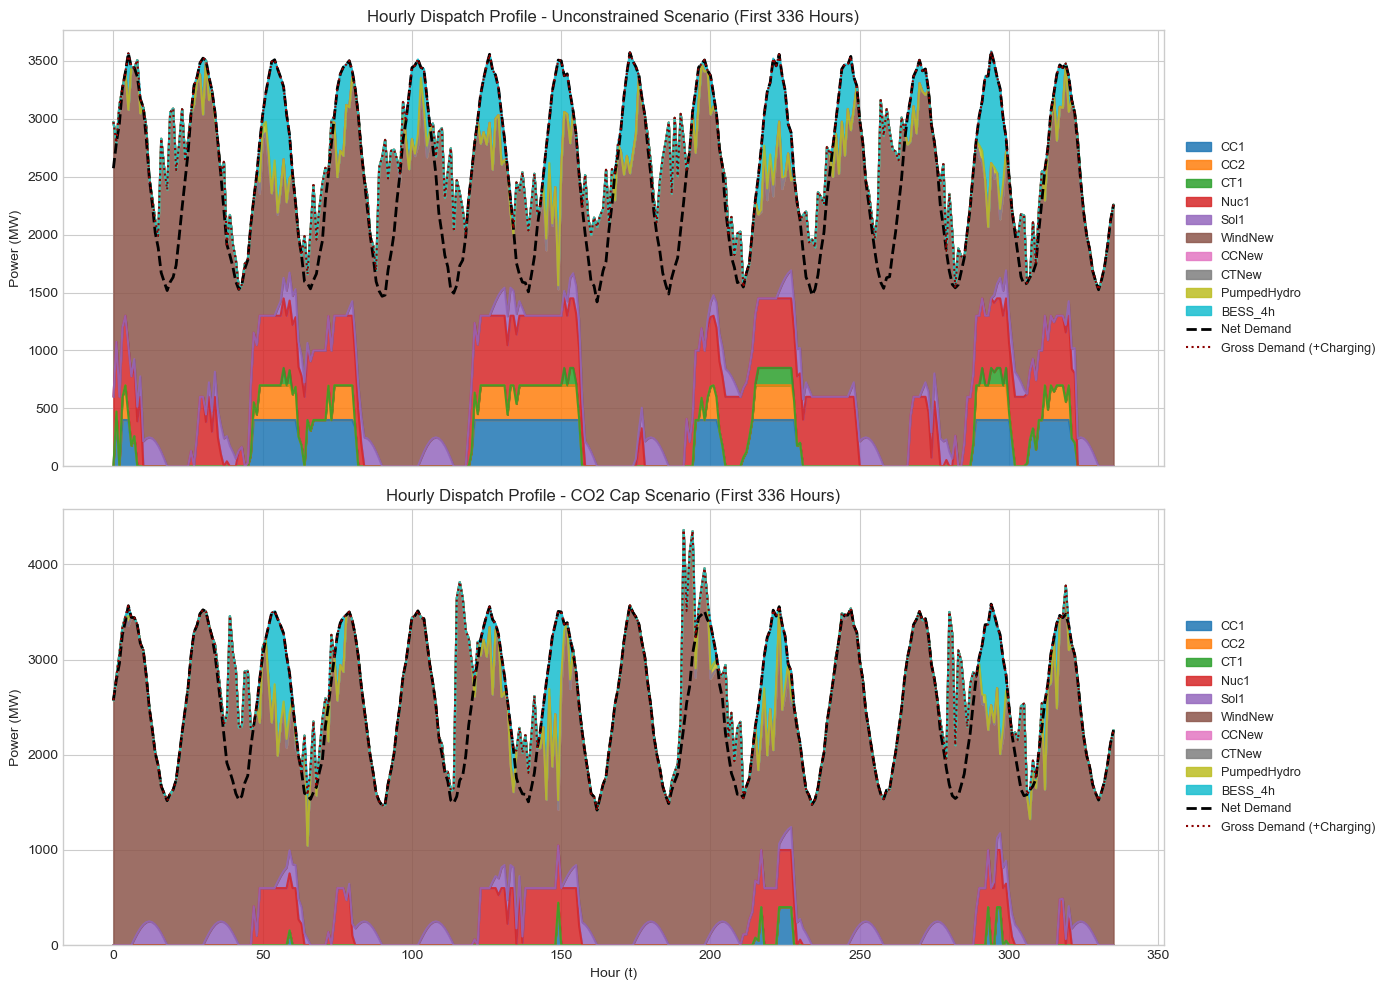

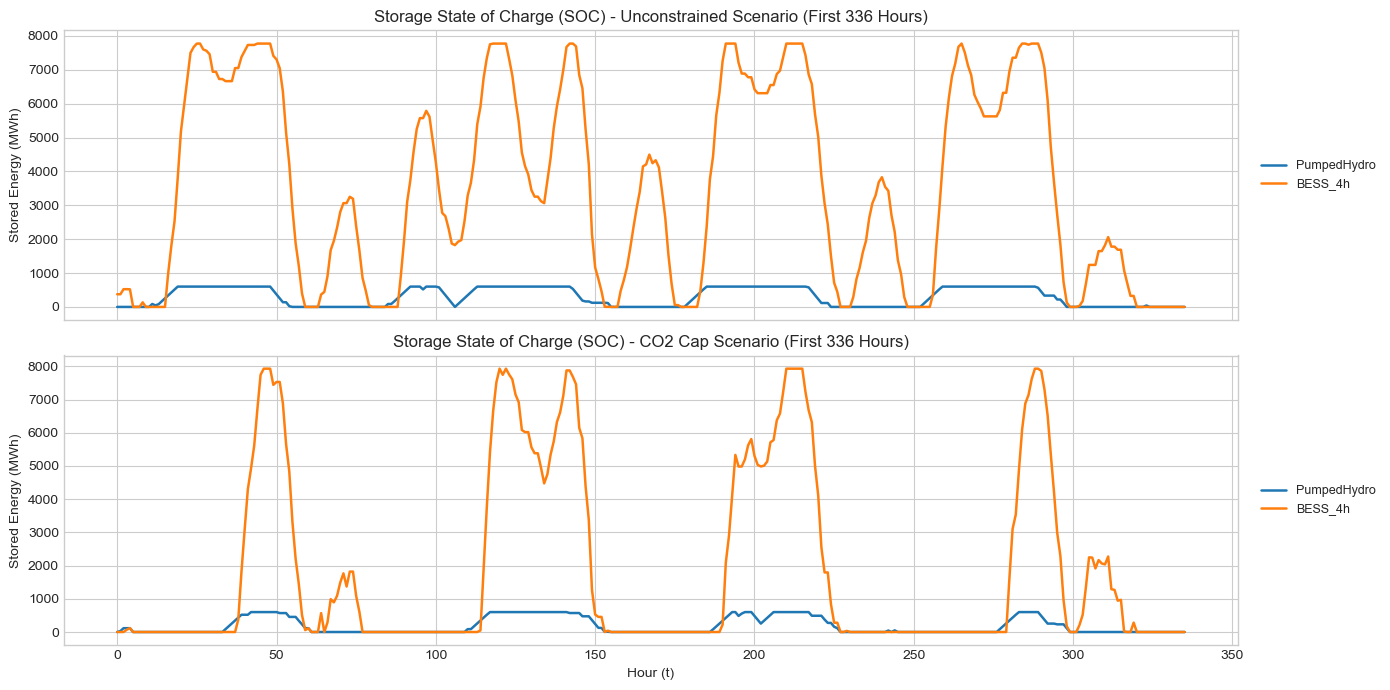

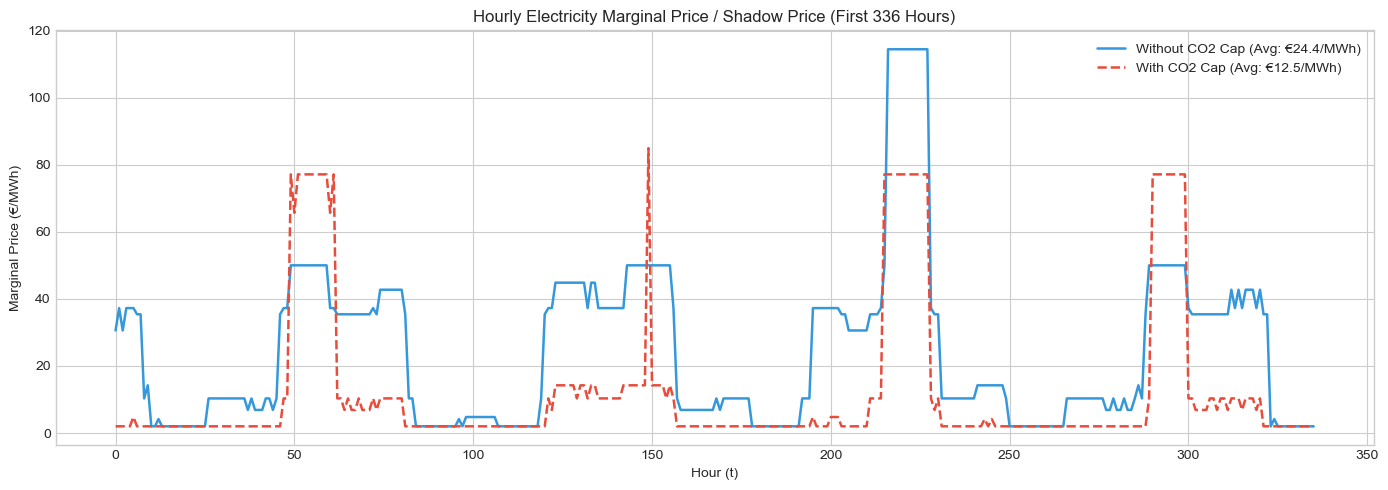

In [3]:
import numpy as np
from schemas import (
    ExistingGenerator,
    CandidateGenerator,
    ExistingStorage,
    CandidateStorage,
    SystemParameters,
    ExpansionInput
)
from CE_model import build_and_solve_expansion
from plot2 import plot_expansion_results


def clean_results(results, target_hours=336):
    """Καθαρίζει τις αρνητικές τιμές και ευθυγραμμίζει τα προφίλ στις ακριβείς ώρες."""
    for attr in ['dispatch_profile_mw', 'charge_profile_mw', 'soc_profile_mwh', 'discharge_profile_mw','curtailment_mw']:
        profile_dict = getattr(results, attr, None)
        if profile_dict and isinstance(profile_dict, dict):
            new_dict = {}
            for item_name, values in profile_dict.items():
                clean_vals = [max(0.0, float(v)) for v in values]
                if len(clean_vals) < target_hours:
                    clean_vals.extend([0.0] * (target_hours - len(clean_vals)))
                else:
                    clean_vals = clean_vals[:target_hours]
                new_dict[item_name] = clean_vals
            setattr(results, attr, new_dict)
    return results


def print_scenario_summary(title: str, results):
    """Βοηθητική συνάρτηση για καθαρή εκτύπωση των αποτελεσμάτων ενός σεναρίου."""
    print("\n" + "=" * 60)
    print(f"📊 {title}")
    print("=" * 60)
    print(f"Solver Status:            {results.status}")
    print(f"Συνολικό Κόστος:          €{results.total_cost:,.2f}")
    print(f"Συνολικές Εκπομπές CO2:  {results.co2_emissions_tons:,.2f} Tons")
    print(f"Μέση Οριακή Τιμή (LMP):  €{results.average_marginal_price:,.2f} / MWh")
    
    print("-" * 60)
    print("🏗️  ΕΠΕΝΔΥΣΕΙΣ ΣΕ ΜΟΝΑΔΕΣ ΠΑΡΑΓΩΓΗΣ (GENERATION):")
    for unit, count in results.units_built.items():
        mw = results.new_capacity_mw.get(unit, 0.0)
        print(f"  • {unit:<10}: {int(count)} μονάδες ({mw:,.0f} MW)")

    print("-" * 60)
    print("🔋 ΕΠΕΝΔΥΣΕΙΣ ΣΕ ΑΠΟΘΗΚΕΥΣΗ (STORAGE):")
    if hasattr(results, 'new_storage_mw') and results.new_storage_mw:
        for s_name, mw in results.new_storage_mw.items():
            mwh = results.new_storage_mwh.get(s_name, 0.0)
            duration = (mwh / mw) if mw > 0 else 0.0
            print(f"  • {s_name:<10}: {mw:,.1f} MW / {mwh:,.1f} MWh ({duration:.1f}h duration)")

    print("-" * 60)
    print("☀️  ΣΥΝΟΛΙΚΟ CURTAILMENT (ΑΝΕΚΜΕΤΑΛΛΕΥΤΟ VRE):")
    if hasattr(results, 'curtailment_mw') and results.curtailment_mw:
        for asset, values in results.curtailment_mw.items():
            total_curt = sum(values)
            print(f"  • {asset:<10}: {total_curt:,.2f} MWh")
    else:
        print("  (καμία μεταβλητή γεννήτρια ή δεν υπολογίστηκε)")
        
    print("-" * 60)
    print("⚡ ΣΥΝΟΛΙΚΗ ΠΑΡΑΓΩΓΗ & EΚΦΟΡΤΙΣΗ (MWh):")
    for asset, mwh in results.generation_mwh.items():
        print(f"  • {asset:<10}: {mwh:,.2f} MWh")
    print("=" * 60)


def run():
    print("🚀 Προετοιμασία δεδομένων...")

    # 1. Χρονοσειρά ζήτησης & ΑΠΕ (336 ώρες)
    hours = 336
    t = np.arange(hours)
    base_demand = 1800 + 700 * np.sin(2 * np.pi * t / 24) + np.random.normal(0, 30, hours)
    demand_profile = (np.maximum(base_demand, 400) * 1.4).tolist()

    solar_cf = np.maximum(0, np.sin(2 * np.pi * (t - 6) / 24)).tolist()
    wind_cf = np.clip(0.40 + 0.20 * np.sin(2 * np.pi * t / 80) + np.random.normal(0, 0.05, hours), 0, 1).tolist()

    vre_profiles = {
        "Sol1": solar_cf,
        "WindNew": wind_cf
    }

    # 2. Υπάρχον Fleet
    existing_fleet = [
        ExistingGenerator(name="CC1", fuel_type="Natural Gas", capacity_mw=400.0, heat_rate=7.2, fuel_cost=4.5, vom_cost=3.0, co2_tons_per_mwh=0.35),
        ExistingGenerator(name="CC2", fuel_type="Natural Gas", capacity_mw=300.0, heat_rate=7.5, fuel_cost=4.5, vom_cost=3.5, co2_tons_per_mwh=0.40),
        ExistingGenerator(name="CT1", fuel_type="Natural Gas", capacity_mw=150.0, heat_rate=10.0, fuel_cost=4.5, vom_cost=5.0, co2_tons_per_mwh=0.75),
        ExistingGenerator(name="Nuc1", fuel_type="Nuclear", capacity_mw=600.0, heat_rate=10.4, fuel_cost=0.8, vom_cost=2.0, co2_tons_per_mwh=0.0),
        ExistingGenerator(name="Sol1", fuel_type="Solar", capacity_mw=250.0, heat_rate=0.0, fuel_cost=0.0, vom_cost=1.0, co2_tons_per_mwh=0.0, is_variable=True)
    ]

    existing_storage = [
        ExistingStorage(name="PumpedHydro", technology="Pumped Hydro", power_capacity_mw=100.0, energy_capacity_mwh=600.0, round_trip_efficiency=0.75, vom_cost_per_mwh=1.5)
    ]

    # 3. Νέες Υποψήφιες Μονάδες
    candidate_fleet = [
        CandidateGenerator(name="WindNew", fuel_type="Wind", unit_capacity_mw=100.0, annual_capex_per_mw=65000.0, op_cost_per_mwh=2.0, co2_tons_per_mwh=0.0, is_variable=True, is_integer=True),
        CandidateGenerator(name="CCNew", fuel_type="Natural Gas", unit_capacity_mw=250.0, annual_capex_per_mw=85000.0, op_cost_per_mwh=35.0, co2_tons_per_mwh=0.30, is_variable=False, is_integer=True),
        CandidateGenerator(name="CTNew", fuel_type="Natural Gas", unit_capacity_mw=100.0, annual_capex_per_mw=45000.0, op_cost_per_mwh=65.0, co2_tons_per_mwh=0.60, is_variable=False, is_integer=True)
    ]

    candidate_storage = [
        CandidateStorage(
            name="BESS_4h",
            technology="Battery",
            annual_capex_per_mw=12000.0,
            annual_capex_per_mwh=3000.0,
            round_trip_efficiency=0.88,
            max_duration_hours=4.0,
            max_power_mw = 2000.0,
            max_energy_mwh = 8000.0,
            vom_cost_per_mwh=0.5,
            degradation_cost_per_mwh=2.0,
            max_cycles_per_year=400.0
        )
    ]

    # ---------------------------------------------------------
    # ΣΕΝΑΡΙΟ 1: Χωρίς CO2 Cap
    # ---------------------------------------------------------
    print("⚙️  [1/2] Επίλυση Σεναρίου ΧΩΡΙΣ CO2 Cap...")
    input_no_cap = ExpansionInput(
        system_params=SystemParameters(prm_margin=1.15, co2_cap_tons=None),
        existing_fleet=existing_fleet,
        candidate_fleet=candidate_fleet,
        existing_storage=existing_storage,
        candidate_storage=candidate_storage,
        demand_profile=demand_profile,
        vre_cfs=vre_profiles
    )
    results_no_cap = clean_results(build_and_solve_expansion(input_no_cap), target_hours=hours)

    # ---------------------------------------------------------
    # ΣΕΝΑΡΙΟ 2: Με Αυστηρό CO2 Cap
    # ---------------------------------------------------------
    co2_limit = 40000.0
    print(f"⚙️  [2/2] Επίλυση Σεναρίου ΜΕ CO2 Cap ({co2_limit:,.0f} Tons)...")
    input_cap = ExpansionInput(
        system_params=SystemParameters(prm_margin=1.15, co2_cap_tons=co2_limit),
        existing_fleet=existing_fleet,
        candidate_fleet=candidate_fleet,
        existing_storage=existing_storage,
        candidate_storage=candidate_storage,
        demand_profile=demand_profile,
        vre_cfs=vre_profiles
    )
    results_cap = clean_results(build_and_solve_expansion(input_cap), target_hours=hours)

    print("\n🔍 DEBUG: Storage Charge/Discharge Totals (Σενάριο CO2 Cap)")
    for s_name in results_cap.charge_profile_mw:
        total_charge = sum(results_cap.charge_profile_mw[s_name])
        total_discharge = sum(results_cap.dispatch_profile_mw.get(s_name, []))
        print(f"  {s_name}: total charge={total_charge:,.1f} MWh, total discharge={total_discharge:,.1f} MWh")
    
    # ---------------------------------------------------------
    # Εκτύπωση Αποτελεσμάτων & Διαγράμματα
    # ---------------------------------------------------------
    print_scenario_summary("ΣΕΝΑΡΙΟ 1: ΧΩΡΙΣ CO2 CAP", results_no_cap)
    print_scenario_summary(f"ΣΕΝΑΡΙΟ 2: ΜΕ CO2 CAP ({co2_limit:,.0f} TONS)", results_cap)

    print("\n📊 Δημιουργία και εμφάνιση διαγραμμάτων...")
    plot_expansion_results(results_no_cap, results_cap, demand_profile, co2_limit, hours_to_plot=hours)


if __name__ == "__main__":
    run()